# Financial News Sentiment Classification
## Notebook 1: Data Preprocessing, EDA, and VADER Baseline

**Project:** ADS-509 Final Project — Team 1  

This notebook covers:
1. Data loading and cleaning
2. Train / validation / test split
3. Exploratory Data Analysis (class distribution, sentence length, word frequencies)
4. Word cloud visualizations
5. VADER rule-based baseline evaluation

## 1. Imports and Setup

In [1]:
import os
import re
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, f1_score
)
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Output directories
FIGURES_DIR = '../figures'
DATA_DIR    = '../data'
os.makedirs(FIGURES_DIR, exist_ok=True)

# Plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
COLORS = {'positive': '#2ecc71', 'negative': '#e74c3c', 'neutral': '#3498db'}

print('Setup complete.')

Setup complete.


## 2. Load and Clean Data

In [3]:
# Financial PhraseBank uses Latin-1 encoding
df = pd.read_csv(
    os.path.join(DATA_DIR, 'all-data.csv'),
    encoding='latin-1',
    header=None,
    names=['sentiment', 'text']
)

print(f'Loaded {len(df):,} rows')
print(df.head())

Loaded 4,846 rows
  sentiment                                               text
0   neutral  According to Gran , the company has no plans t...
1   neutral  Technopolis plans to develop in stages an area...
2  negative  The international electronic industry company ...
3  positive  With the new production plant the company woul...
4  positive  According to the company 's updated strategy f...


In [4]:
# --- Cleaning ---
# Normalize whitespace
df['text'] = df['text'].str.strip().str.replace(r'\s+', ' ', regex=True)

# Standardize label casing
df['sentiment'] = df['sentiment'].str.strip().str.lower()

# Drop any exact duplicates
before = len(df)
df.drop_duplicates(subset='text', inplace=True)
print(f'Removed {before - len(df)} duplicate rows → {len(df):,} remaining')

# Confirm no missing values
print('\nMissing values:')
print(df.isnull().sum())

# Add derived features for EDA
df['char_count']  = df['text'].str.len()
df['word_count']  = df['text'].str.split().str.len()

df.head()

Removed 8 duplicate rows → 4,838 remaining

Missing values:
sentiment    0
text         0
dtype: int64


,sentiment,text,char_count,word_count
0,neutral,"According to Gran , the company has no plans t...",127,25
1,neutral,Technopolis plans to develop in stages an area...,190,31
2,negative,The international electronic industry company ...,228,36
3,positive,With the new production plant the company woul...,206,33
4,positive,According to the company 's updated strategy f...,203,41


In [5]:
# Label encoding (for use in Notebook 2)
label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
df['label'] = df['sentiment'].map(label_map)

print('Label encoding:', label_map)
print(df[['sentiment', 'label']].value_counts())

Label encoding: {'negative': 0, 'neutral': 1, 'positive': 2}
sentiment  label
neutral    1        2872
positive   2        1362
negative   0         604
Name: count, dtype: int64


## 3. Train / Validation / Test Split (70 / 15 / 15)

In [6]:
# Stratified split to preserve class proportions
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=SEED, stratify=df['label']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=SEED, stratify=temp_df['label']
)

print(f'Train : {len(train_df):,} ({len(train_df)/len(df):.1%})')
print(f'Val   : {len(val_df):,}   ({len(val_df)/len(df):.1%})')
print(f'Test  : {len(test_df):,}   ({len(test_df)/len(df):.1%})')

# Save splits for Notebook 2
train_df.to_csv(os.path.join(DATA_DIR, 'train.csv'), index=False)
val_df.to_csv(os.path.join(DATA_DIR, 'val.csv'),   index=False)
test_df.to_csv(os.path.join(DATA_DIR, 'test.csv'),  index=False)
print('Splits saved to data/')

Train : 3,386 (70.0%)
Val   : 726   (15.0%)
Test  : 726   (15.0%)
Splits saved to data/


## 4. Exploratory Data Analysis

### 4.1 Class Distribution

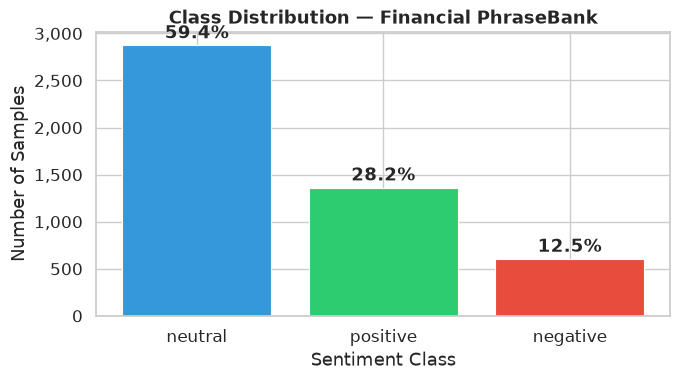

Note: Dataset is imbalanced — Negative class (~12.5%) is underrepresented.


In [7]:
class_counts = df['sentiment'].value_counts().reindex(['neutral', 'positive', 'negative'])
class_pcts   = class_counts / len(df) * 100

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    class_counts.index,
    class_counts.values,
    color=[COLORS[s] for s in class_counts.index],
    edgecolor='white', linewidth=0.8
)
for bar, pct in zip(bars, class_pcts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        f'{pct:.1f}%', ha='center', va='bottom', fontweight='bold'
    )
ax.set_title('Class Distribution — Financial PhraseBank', fontsize=13, fontweight='bold')
ax.set_xlabel('Sentiment Class')
ax.set_ylabel('Number of Samples')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'class_distribution.png'), dpi=150)
plt.show()
print('Note: Dataset is imbalanced — Negative class (~12.5%) is underrepresented.')

### 4.2 Sentence Length Distribution

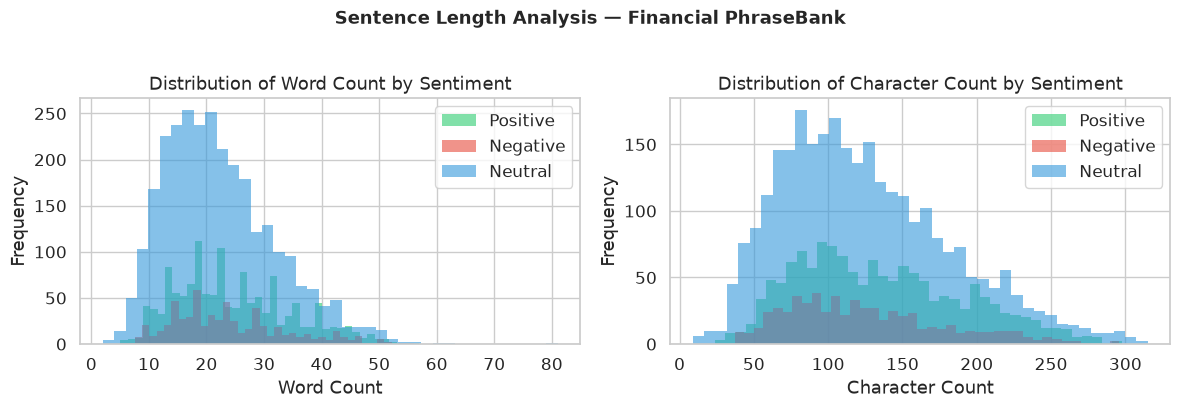

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, label in zip(axes, ['word_count', 'char_count'], ['Word Count', 'Character Count']):
    for sent, color in COLORS.items():
        subset = df[df['sentiment'] == sent][col]
        ax.hist(subset, bins=40, alpha=0.6, color=color, label=sent.capitalize(), edgecolor='none')
    ax.set_xlabel(label)
    ax.set_ylabel('Frequency')
    ax.set_title(f'Distribution of {label} by Sentiment')
    ax.legend()

plt.suptitle('Sentence Length Analysis — Financial PhraseBank', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'sentence_length_hist.png'), dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Summary statistics by class
print('Word count statistics by sentiment class:')
df.groupby('sentiment')['word_count'].describe().round(1)

Word count statistics by sentiment class:


,count,mean,std,min,25%,50%,75%,max
sentiment,,,,,,,,
negative,604.0,23.9,9.9,5.0,17.0,22.0,30.0,56.0
neutral,2872.0,22.2,9.8,2.0,15.0,21.0,28.0,81.0
positive,1362.0,24.7,10.1,5.0,17.0,23.0,31.0,57.0


### 4.3 Top Frequent Words by Class

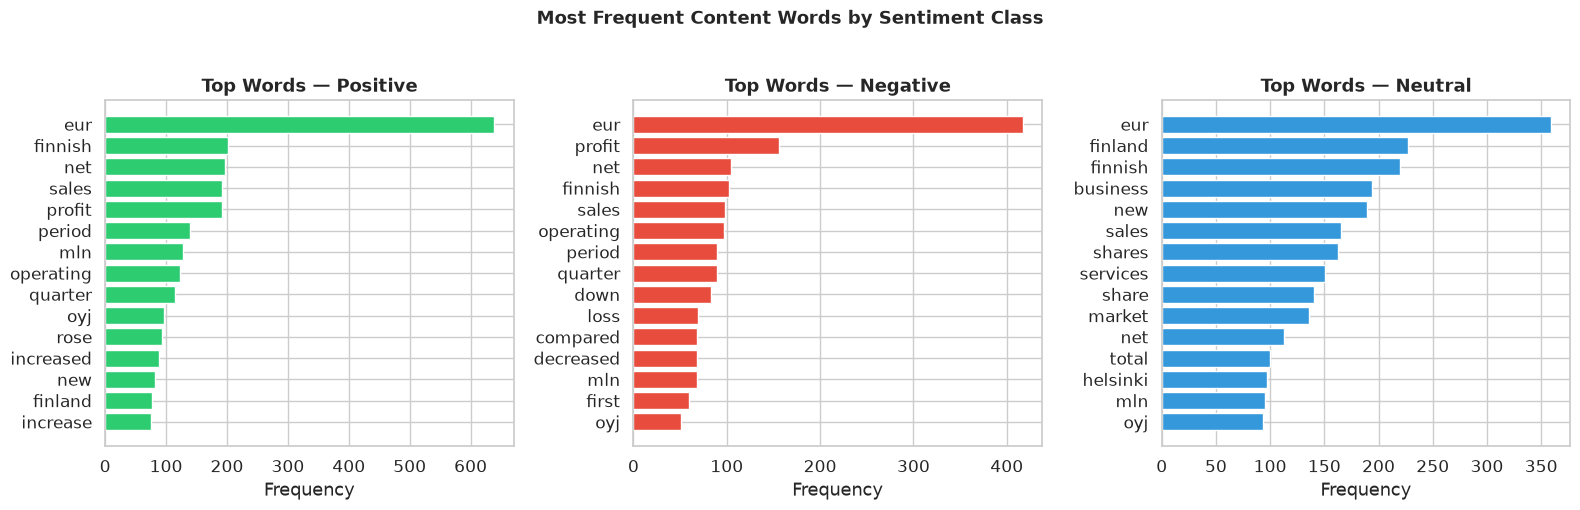

In [10]:
STOPWORDS = {
    'the','a','an','and','or','but','in','on','at','to','for','of','with',
    'is','was','are','were','be','been','has','have','had','it','its',
    'that','this','from','by','as','not','will','would','also','said',
    'which','their','they','he','she','we','our','than','after','before',
    'into','about','company','group','per','cent','year','million','billion'
}

def top_words(texts, n=15):
    tokens = [
        w.lower() for sent in texts
        for w in re.findall(r'[a-z]+', sent.lower())
        if w not in STOPWORDS and len(w) > 2
    ]
    return Counter(tokens).most_common(n)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (sent, color) in zip(axes, COLORS.items()):
    words, counts = zip(*top_words(df[df['sentiment'] == sent]['text']))
    ax.barh(words[::-1], counts[::-1], color=color, edgecolor='white')
    ax.set_title(f'Top Words — {sent.capitalize()}', fontweight='bold')
    ax.set_xlabel('Frequency')

plt.suptitle('Most Frequent Content Words by Sentiment Class', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'top_words_by_class.png'), dpi=150, bbox_inches='tight')
plt.show()

### 4.4 Word Cloud Visualizations

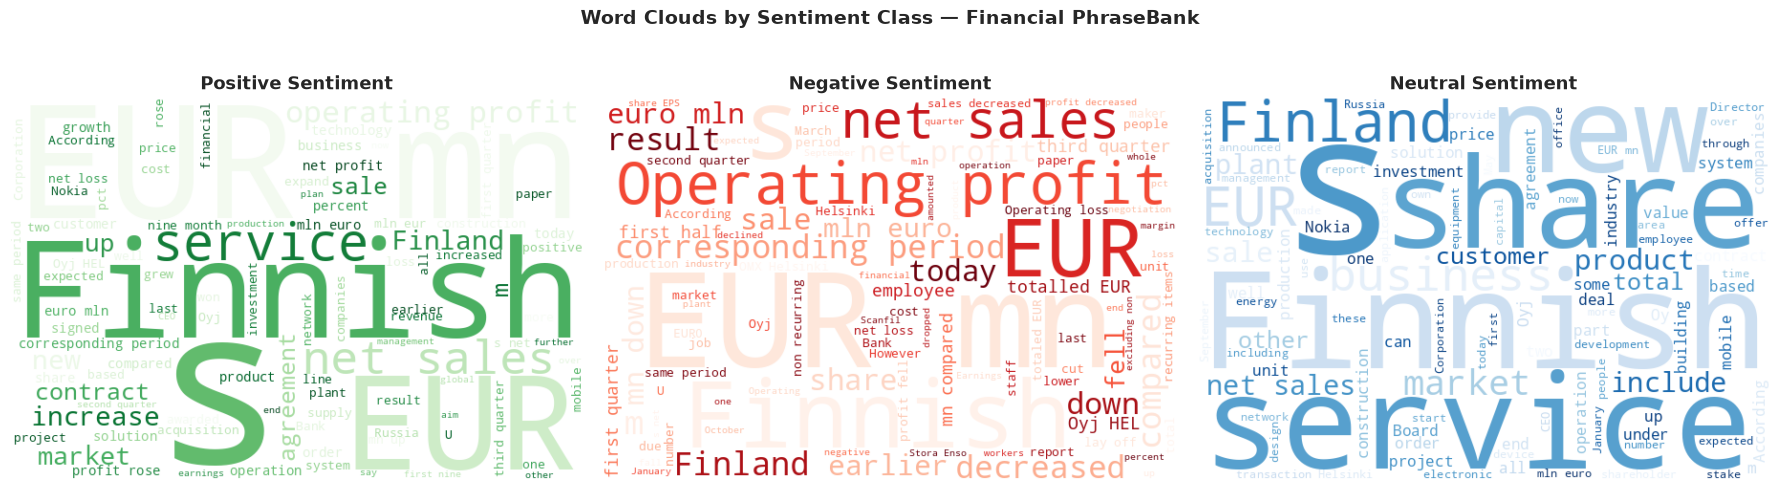

In [11]:
wc_colors = {'positive': 'Greens', 'negative': 'Reds', 'neutral': 'Blues'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (sent, cmap) in zip(axes, wc_colors.items()):
    text_corpus = ' '.join(df[df['sentiment'] == sent]['text'])
    wc = WordCloud(
        width=600, height=400,
        background_color='white',
        colormap=cmap,
        stopwords=STOPWORDS,
        max_words=100,
        random_state=SEED
    ).generate(text_corpus)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{sent.capitalize()} Sentiment', fontsize=13, fontweight='bold')
    # Save individual wordclouds too
    wc.to_file(os.path.join(FIGURES_DIR, f'wordcloud_{sent}.png'))

plt.suptitle('Word Clouds by Sentiment Class — Financial PhraseBank',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'wordclouds_combined.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. VADER Baseline

VADER (Valence Aware Dictionary and Sentiment Reasoner) is a rule-based sentiment tool optimized for social media and general English text. We use it as a baseline to quantify how much domain-specific fine-tuning (FinBERT) helps on financial language.

In [12]:
analyzer = SentimentIntensityAnalyzer()

def vader_predict(text, pos_thresh=0.05, neg_thresh=-0.05):
    """Map VADER compound score to Positive / Neutral / Negative."""
    compound = analyzer.polarity_scores(text)['compound']
    if compound >= pos_thresh:
        return 'positive'
    elif compound <= neg_thresh:
        return 'negative'
    else:
        return 'neutral'

# Apply on test set
test_df = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))
test_df['vader_pred'] = test_df['text'].apply(vader_predict)

print(f'VADER predictions on {len(test_df):,} test samples')
test_df[['text', 'sentiment', 'vader_pred']].head(10)

VADER predictions on 726 test samples


,text,sentiment,vader_pred
0,ITG 's share in the deal is estimated at some ...,neutral,positive
1,"In addition , the company will reduce a maximu...",negative,neutral
2,Net sales decreased to EUR 91.6 mn from EUR 10...,negative,neutral
3,Finnish printed circuit boards ( PCBs ) maker ...,neutral,neutral
4,Kaupthing Bank will publish its annual results...,neutral,neutral
5,A 2001 agreement expired earlier this month .,neutral,positive
6,CapMan said the deal 's effect on its cash flo...,neutral,positive
7,The company is well positioned in Brazil and U...,positive,positive
8,"If Honkarakenne starts production there , it w...",neutral,neutral
9,Following the increase the company+EUR TM s c...,neutral,positive


In [13]:
y_true  = test_df['sentiment']
y_vader = test_df['vader_pred']

vader_acc = accuracy_score(y_true, y_vader)
vader_f1  = f1_score(y_true, y_vader, average='macro', labels=['negative','neutral','positive'])

print(f'VADER Accuracy : {vader_acc:.4f}')
print(f'VADER Macro F1 : {vader_f1:.4f}')
print()
print(classification_report(y_true, y_vader, labels=['negative','neutral','positive']))

VADER Accuracy : 0.5510
VADER Macro F1 : 0.4815

              precision    recall  f1-score   support

    negative       0.39      0.24      0.30        91
     neutral       0.75      0.53      0.62       431
    positive       0.41      0.73      0.52       204

    accuracy                           0.55       726
   macro avg       0.52      0.50      0.48       726
weighted avg       0.61      0.55      0.55       726



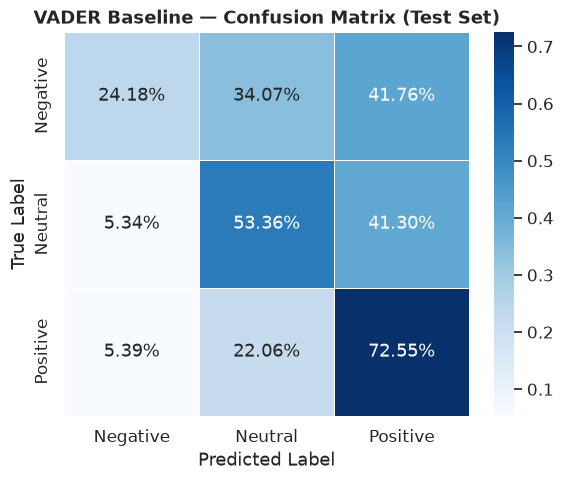

In [14]:
# Confusion matrix
labels_ordered = ['negative', 'neutral', 'positive']
cm = confusion_matrix(y_true, y_vader, labels=labels_ordered)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm_pct, annot=True, fmt='.2%', cmap='Blues',
    xticklabels=[l.capitalize() for l in labels_ordered],
    yticklabels=[l.capitalize() for l in labels_ordered],
    ax=ax, linewidths=0.5
)
ax.set_title('VADER Baseline — Confusion Matrix (Test Set)', fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'vader_confusion_matrix.png'), dpi=150)
plt.show()

In [15]:
# Save VADER results for comparison in Notebook 2
vader_results = {
    'model': 'VADER Baseline',
    'accuracy': round(vader_acc, 4),
    'macro_f1': round(vader_f1, 4)
}
pd.DataFrame([vader_results]).to_csv(os.path.join(DATA_DIR, 'vader_results.csv'), index=False)
print('VADER results saved to data/vader_results.csv')
print(vader_results)

VADER results saved to data/vader_results.csv
{'model': 'VADER Baseline', 'accuracy': 0.551, 'macro_f1': 0.4815}


## 6. Summary

| Step | Outcome |
|------|---------|
| Dataset loaded | 4,840 sentences, cleaned, no missing values |
| Splits saved | 70% train / 15% val / 15% test (stratified) |
| Class imbalance | Negative underrepresented (~12.5%) — handled via class weights in Notebook 2 |
| VADER Accuracy | See above |
| VADER Macro F1 | See above — expected to be low due to financial domain mismatch |

**Next step:** Notebook 2 fine-tunes `distilbert-base-uncased` on the training split and compares against this VADER baseline.